In [1]:
import os
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
def load_data_from_folder(folder_path):
    X = []
    y = []
    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.endswith('.npy'):
                    data = np.load(os.path.join(label_path, file))
                    
                    # THAY ĐỔI Ở ĐÂY: TDÙNG MEAN
                    # Tính trung bình và độ lệch chuẩn theo trục thời gian (axis=1)
                    mean = np.mean(data, axis=1)
                    std = np.std(data, axis=1)
                    features = np.concatenate([mean, std]) # Kết hợp lại
                    
                    X.append(features) 
                    y.append(label)
    return np.array(X), np.array(y)

# Đường dẫn của bạn
train_path = r"C:\Users\Hoannd\Downloads\ail\git_project\-the-adults-cried\official_project_v1\ail\extract\data_extract\bfcc\run_4\data"
x, y = load_data_from_folder(train_path)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 96, stratify= y)
le = LabelEncoder()
y_train_encoder = le.fit_transform(y_train)
y_test_encoder = le.transform(y_test)

# test_path = r"C:\hoctap\learn_AI\My_project\Learn_AIL\-the-adults-cried\official_project_v1\ail\extract\data_extract\mfcc\test_npy\run_1\data"
# X_train, y_train = load_data_from_folder(train_path)
# X_test, y_test = load_data_from_folder(test_path)
# le = LabelEncoder()
# y_train_encoded = le.fit_transform(y_train) 
# y_test_encoded = le.transform(y_test)



ModuleNotFoundError: No module named 'matplotlib.pyplot'

In [5]:
print("Total:", len(x))
print("Train:", len(x_train))
print("Test:", len(x_test))

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts())

Total: 2242
Train: 1793
Test: 449

Train distribution:
hungry        593
belly_pain    200
discomfort    200
scared        200
lonely        200
tired         200
burping       200
Name: count, dtype: int64

Test distribution:
hungry        149
tired          50
scared         50
discomfort     50
burping        50
belly_pain     50
lonely         50
Name: count, dtype: int64


In [6]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC()) 
])

# Cấu hình fineturn . cứ thêm chữ clf__parameter vô  
param_grid = [
    {
        'clf': [SVC()],
        'clf__kernel': ['rbf', 'poly'],
        'clf__C': [0.1, 1, 10],
        'clf__gamma': ['scale', 'auto']
    },
    {
        'clf': [RandomForestClassifier(random_state=100)],
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [None, 10, 20],
        'clf__criterion': ['gini', 'entropy']
    },
    {
        'clf': [KNeighborsClassifier()],
        'clf__n_neighbors': [3, 5, 7, 9, 11],
        'clf__metric': ['minkowski', 'manhattan'],
        'clf__weights': ['uniform', 'distance']
    },
]


grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv= 5, 
    scoring='f1_macro', # Hoặc 'f1_macro' nếu dữ liệu lệch
    verbose=2,
    n_jobs=-1 # này tự chỉnh cpu. Chỉnh -1 là max công suất cổng. bao nhiêu cổng thì chỉnh lại 
)

grid_search.fit(x_train, y_train_encoder)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

print(f"Best Model: {grid_search.best_params_['clf']}")
print(f"Best CV Score: {grid_search.best_score_}")

print(classification_report(
    y_test_encoder,
    y_pred,
    target_names=le.classes_
))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Model: SVC()
Best CV Score: 0.8760097282580851
              precision    recall  f1-score   support

  belly_pain       0.91      0.84      0.88        50
     burping       0.96      0.92      0.94        50
  discomfort       0.78      0.76      0.77        50
      hungry       0.82      0.96      0.89       149
      lonely       0.96      0.88      0.92        50
      scared       0.98      0.94      0.96        50
       tired       0.79      0.60      0.68        50

    accuracy                           0.87       449
   macro avg       0.88      0.84      0.86       449
weighted avg       0.87      0.87      0.87       449



Đang vẽ Confusion Matrix...


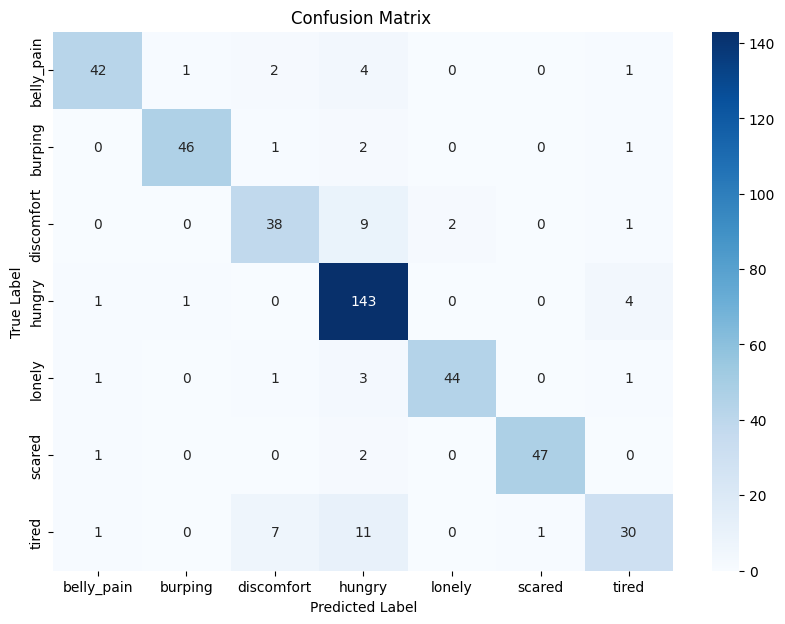

In [7]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Vẽ biểu đồ Confusion Matrix trực quan bằng Seaborn Heatmap.
    """
    # Tính toán ma trận
    cm = confusion_matrix(y_true, y_pred)
    
    # Cấu hình biểu đồ
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.title('Confusion Matrix ')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# --- LUỒNG CHẠY TIẾP THEO CỦA PIPELINE ---

# Sau khi bạn đã có y_pred và best_model từ code trước:
# Giả sử le là LabelEncoder bạn đã dùng để encode label

print("Đang vẽ Confusion Matrix...")
plot_confusion_matrix(y_test_encoder, y_pred, le.classes_)

Total: 2242
Train: 1793
Test: 449

Train distribution:
hungry        593
belly_pain    200
discomfort    200
scared        200
lonely        200
tired         200
burping       200
Name: count, dtype: int64

Test distribution:
hungry        149
tired          50
scared         50
discomfort     50
burping        50
belly_pain     50
lonely         50
Name: count, dtype: int64

Đang train model: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

>>> MODEL: SVM
Best Params:
{'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV Score (f1_macro): 0.8760
Test F1 Macro: 0.8607

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.91      0.84      0.88        50
     burping       0.96      0.92      0.94        50
  discomfort       0.78      0.76      0.77        50
      hungry       0.82      0.96      0.89       149
      lonely       0.96      0.88      0.92        50
      scared       0.98      0.94      0.96 

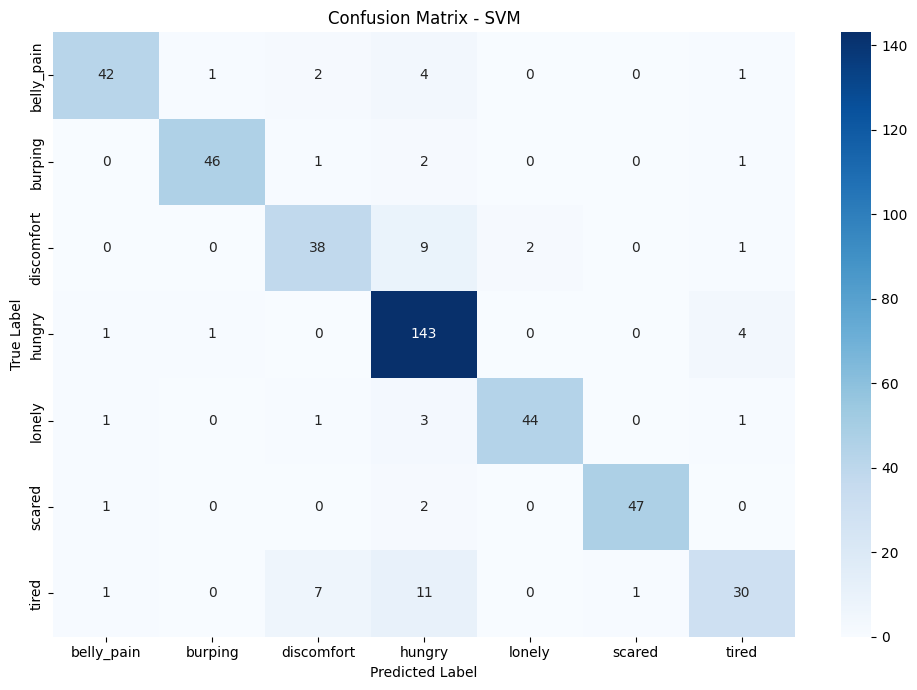


Đang train model: RandomForest
Fitting 5 folds for each of 18 candidates, totalling 90 fits

>>> MODEL: RandomForest
Best Params:
{'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__n_estimators': 100}
Best CV Score (f1_macro): 0.8664
Test F1 Macro: 0.8709

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.90      0.86      0.88        50
     burping       0.96      0.94      0.95        50
  discomfort       0.81      0.76      0.78        50
      hungry       0.82      1.00      0.90       149
      lonely       1.00      0.82      0.90        50
      scared       0.96      0.88      0.92        50
       tired       0.92      0.66      0.77        50

    accuracy                           0.88       449
   macro avg       0.91      0.85      0.87       449
weighted avg       0.89      0.88      0.88       449



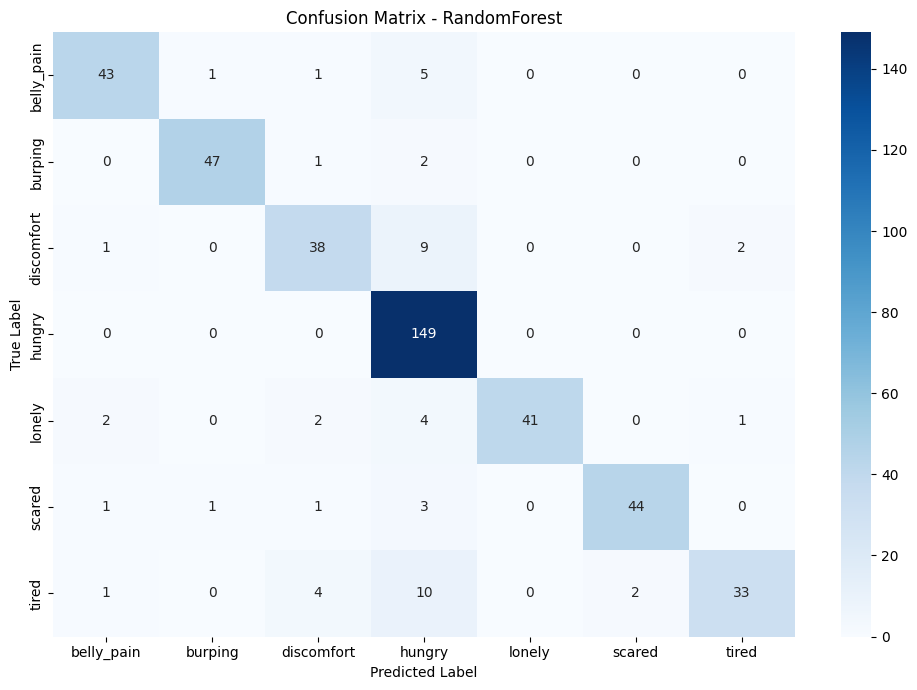


Đang train model: KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits

>>> MODEL: KNN
Best Params:
{'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Best CV Score (f1_macro): 0.8318
Test F1 Macro: 0.8334

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.81      0.84      0.82        50
     burping       0.90      0.92      0.91        50
  discomfort       0.76      0.78      0.77        50
      hungry       0.83      0.93      0.88       149
      lonely       0.93      0.84      0.88        50
      scared       0.94      0.88      0.91        50
       tired       0.80      0.56      0.66        50

    accuracy                           0.85       449
   macro avg       0.85      0.82      0.83       449
weighted avg       0.85      0.85      0.84       449



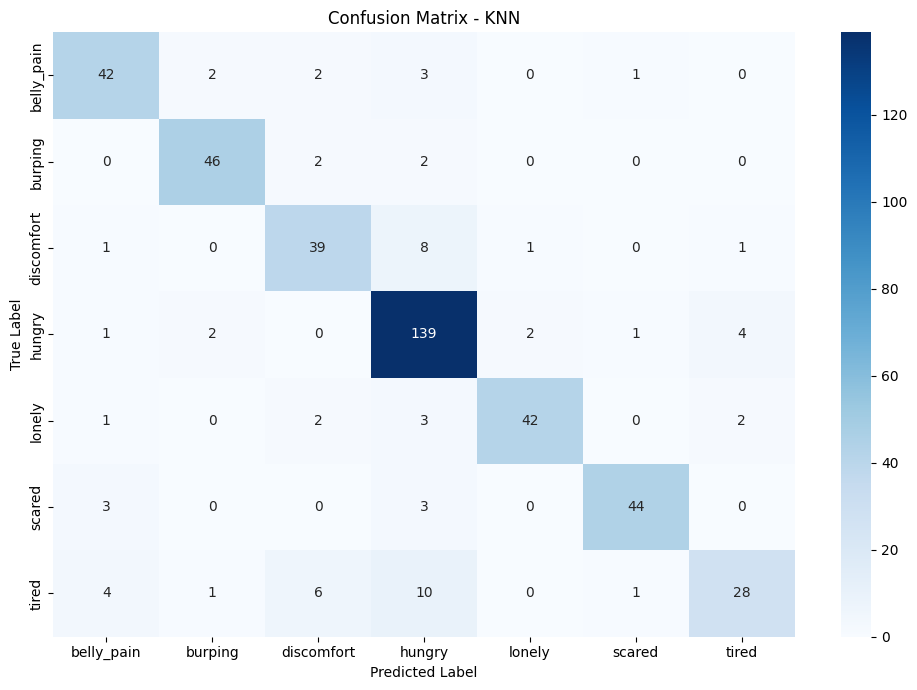


Đang train model: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

>>> MODEL: LogisticRegression

c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Hoannd\Ap


Best Params:
{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV Score (f1_macro): 0.5611
Test F1 Macro: 0.5147

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.55      0.58      0.56        50
     burping       0.61      0.40      0.48        50
  discomfort       0.34      0.30      0.32        50
      hungry       0.81      0.95      0.87       149
      lonely       0.54      0.64      0.59        50
      scared       0.53      0.52      0.53        50
       tired       0.31      0.22      0.26        50

    accuracy                           0.61       449
   macro avg       0.53      0.52      0.51       449
weighted avg       0.59      0.61      0.59       449



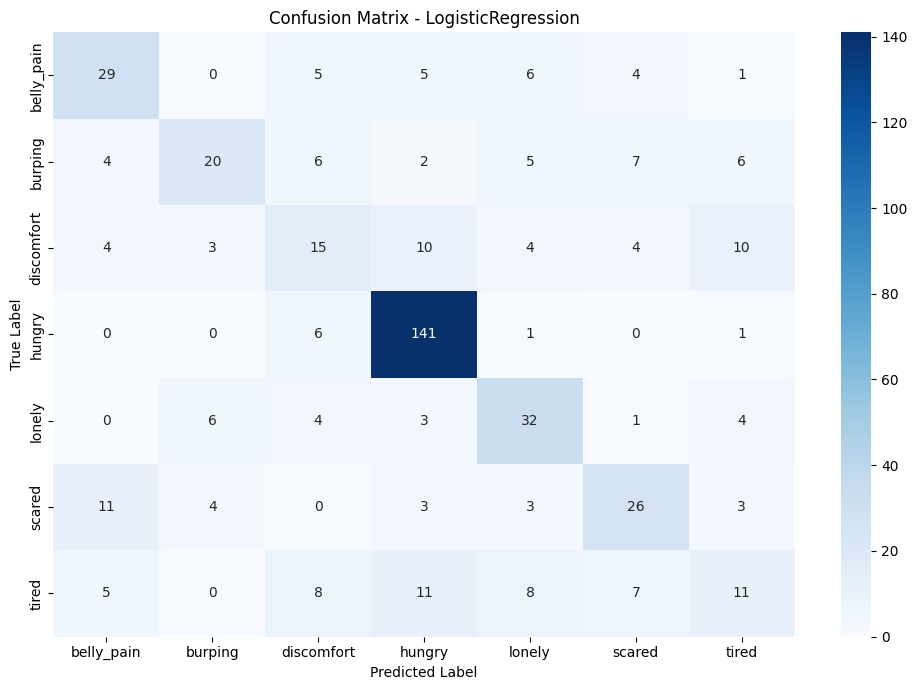


Đang train model: XGBoost
Fitting 5 folds for each of 72 candidates, totalling 360 fits

>>> MODEL: XGBoost
Best Params:
{'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.2, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV Score (f1_macro): 0.8504
Test F1 Macro: 0.8417

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.91      0.84      0.88        50
     burping       0.98      0.86      0.91        50
  discomfort       0.74      0.74      0.74        50
      hungry       0.82      0.97      0.89       149
      lonely       0.89      0.84      0.87        50
      scared       0.92      0.90      0.91        50
       tired       0.83      0.60      0.70        50

    accuracy                           0.86       449
   macro avg       0.87      0.82      0.84       449
weighted avg       0.86      0.86      0.85       449



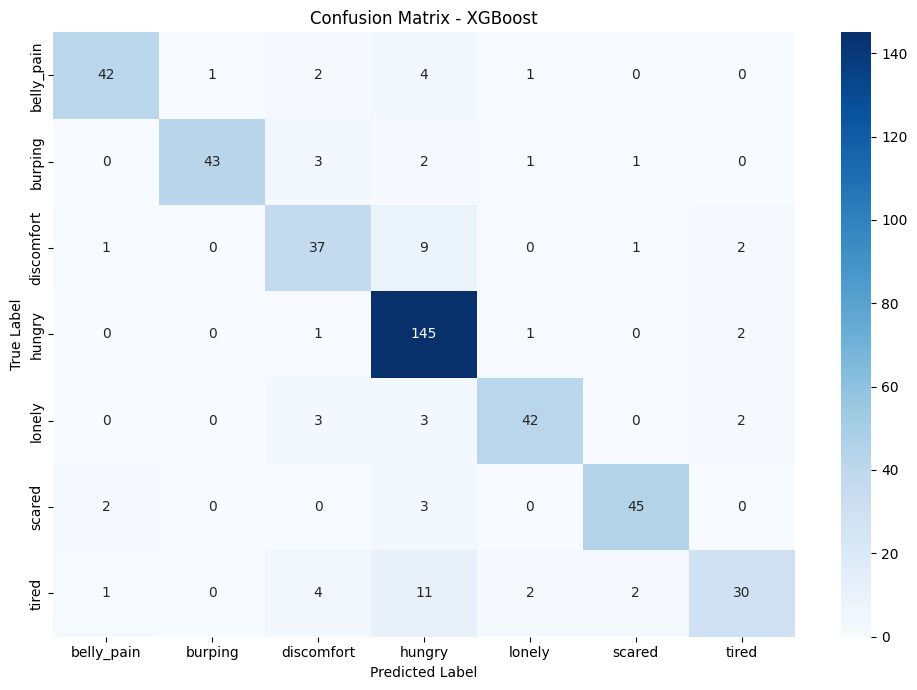


TỔNG HỢP KẾT QUẢ
                Model  Best CV Score  Test F1 Macro
1        RandomForest       0.866351       0.870866
0                 SVM       0.876010       0.860653
4             XGBoost       0.850390       0.841744
2                 KNN       0.831820       0.833417
3  LogisticRegression       0.561122       0.514682

Chi tiết best params:

Model: RandomForest
Best Params: {'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__n_estimators': 100}

Model: SVM
Best Params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Model: XGBoost
Best Params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.2, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 0.8}

Model: KNN
Best Params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}

Model: LogisticRegression
Best Params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score

from xgboost import XGBClassifier


def load_data_from_folder(folder_path):
    X = []
    y = []

    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.endswith(".npy"):
                    data = np.load(os.path.join(label_path, file))

                    mean = np.mean(data, axis=1)
                    std = np.std(data, axis=1)
                    features = np.concatenate([mean, std])

                    X.append(features)
                    y.append(label)

    return np.array(X), np.array(y)


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


# =========================
# LOAD DATA
# =========================
train_path = r"C:\Users\Hoannd\Downloads\ail\git_project\-the-adults-cried\official_project_v1\ail\extract\data_extract\bfcc\run_4\data"

X, y = load_data_from_folder(train_path)

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=96,
    stratify=y
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Total:", len(X))
print("Train:", len(x_train))
print("Test:", len(x_test))

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts())


# =========================
# PARAM GRID RIÊNG TỪNG MODEL
# =========================
model_configs = {
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC())
        ]),
        "param_grid": {
            "clf__kernel": ["rbf", "poly"],
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", "auto"]
        }
    },

    "RandomForest": {
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=100))
        ]),
        "param_grid": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [None, 10, 20],
            "clf__criterion": ["gini", "entropy"]
        }
    },

    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": [3, 5, 7, 9, 11],
            "clf__metric": ["minkowski", "manhattan"],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "LogisticRegression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=100))
        ]),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__solver": ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"]
        }
    },

    "XGBoost": {
        "pipeline": Pipeline([
            ("clf", XGBClassifier(
                random_state=100,
                eval_metric="mlogloss"
            ))
        ]),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0]
        }
    }
}


# =========================
# CHẠY RIÊNG TỪNG MODEL
# =========================
results = []

for model_name, config in model_configs.items():
    print("\n" + "=" * 60)
    print(f"Đang train model: {model_name}")
    print("=" * 60)

    grid_search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        cv=5,
        scoring="f1_macro",
        verbose=2,
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train_encoded)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_test)

    test_f1_macro = f1_score(y_test_encoded, y_pred, average="macro")

    print(f"\n>>> MODEL: {model_name}")
    print("Best Params:")
    print(grid_search.best_params_)
    print(f"Best CV Score (f1_macro): {grid_search.best_score_:.4f}")
    print(f"Test F1 Macro: {test_f1_macro:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test_encoded,
        y_pred,
        target_names=le.classes_
    ))

    plot_confusion_matrix(
        y_test_encoded,
        y_pred,
        le.classes_,
        title=f"Confusion Matrix - {model_name}"
    )

    results.append({
        "Model": model_name,
        "Best CV Score": grid_search.best_score_,
        "Test F1 Macro": test_f1_macro,
        "Best Params": grid_search.best_params_
    })


# =========================
# BẢNG TỔNG HỢP
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test F1 Macro", ascending=False)

print("\n" + "=" * 60)
print("TỔNG HỢP KẾT QUẢ")
print("=" * 60)
print(results_df[["Model", "Best CV Score", "Test F1 Macro"]])

print("\nChi tiết best params:")
for _, row in results_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"Best Params: {row['Best Params']}")